In [1]:
!pip install sentencepiece

In [1]:
import os
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

from nltk.metrics.distance import edit_distance
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, MT5ForConditionalGeneration

2026-02-25 11:27:07.113484: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-25 11:27:07.142551: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 11:27:08.168429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 11:27:10.318750: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
def loadData():
    df = pd.read_csv("../Combined.csv")

    df = df.sample(frac=1, random_state=27)
    df.reset_index(inplace=True)
    df.pop("index")

    df = df[["romanized", "devanagari"]]
    df.columns = ["input", "label"]
    train_df = df[:-200]
    val_df = df[-200:]

    mask = train_df.input.str.len() > 300
    val_df = pd.concat([val_df, train_df[mask]], ignore_index=True)
    train_df = train_df[~mask]

    return train_df, val_df

In [4]:
train_df, val_df = loadData()

In [5]:
print(len(train_df), len(val_df))
print(train_df.head())

8410 200
                                               input  \
0  sombaar dekhi haami aafno naksha tayar garna t...   
1  dai ayuta bagh kinnu paryo ani balla ghar ma d...   
2  aaja press meet ma coalition ko roadmap bare n...   
3  kathmandu ko baneshwor maa IT park ra startup ...   
4  flood prone area maa community maa early warni...   

                                               label  
0      सोमबार देखि हामी आफ्नो नक्शा तयार गर्न थाल्छौ  
1  दाई एउटा बाघ किन्नुपर्छ अनि बल्ल घरमा दिनदिनै ...  
2   आज प्रेस मिट मा कोएलिसन को रोडम्याप बारे नेता...  
3   काठमाडौंको बानेश्वरमा आईटी पार्क र स्टार्टअप ...  
4   फ्लड प्रोन् एरिया मा समुदायमा अर्ली वार्निङ स...  


In [6]:
class MyDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return row.input, row.label

class DataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch: List[Tuple[str, str]]) -> Dict[str, torch.Tensor]:
        inputs = [input for input, _ in batch]
        labels = [label for _, label in batch]
        encodings = self.tokenizer(inputs, padding="longest", return_tensors="pt")
        label_encodings = self.tokenizer(labels, padding="longest", return_tensors="pt")

        input_ids = encodings.input_ids
        attention_mask = encodings.attention_mask
        labels = label_encodings.input_ids
        labels[labels == self.tokenizer.pad_token_id] = -100
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [4]:
device = torch.device("cpu")

def model_init(checkpoint):
    model = MT5ForConditionalGeneration.from_pretrained(checkpoint)
    return model.to(device)

def dict_to_cuda(batch):
    return {k: v.to(device) for k, v in batch.items()}

In [8]:
@torch.no_grad()
def eval_model(model, val_loader, tokenizer):
    model.eval()
    total = 0
    count = 0
    stream = tqdm(val_loader)
    for batch in stream:
        batch = dict_to_cuda(batch)
        loss = model(**batch).loss
        total += loss.item()
        count += 1
        stream.set_description_str(desc=f"val_edit_dist {total / count:.3f}")

    model.train()
    return total / count

In [5]:
checkpoint = "google/mt5-small"
tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=False)
model = model_init(checkpoint)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
train_ds = MyDataset(train_df)
val_ds = MyDataset(val_df)
data_collator = DataCollator(tokenizer)
train_loader = DataLoader(train_ds, batch_size=2, collate_fn=data_collator)
val_loader = DataLoader(val_ds, batch_size=8, collate_fn=data_collator)

NameError: name 'MyDataset' is not defined

In [ ]:
max_epochs = 5
best = float("inf")
trigger = 0

for epoch in range(max_epochs):
    stream = tqdm(train_loader)
    total = 0
    count = 0
    for batch in stream:
        batch = dict_to_cuda(batch)
        loss = model(**batch).loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
        count += 1
        stream.set_description_str(
            f"Epoch {epoch}/{max_epochs} | Loss {total / count : .3f}"
        )
    loss = total / count
    eval_metric = eval_model(model, val_loader, tokenizer)
    print(
        f"Epoch {epoch}/{max_epochs} | Loss {loss: .3f} | Val Loss {eval_metric: .4f}"
    )

    trigger += 1

    if eval_metric < best:
        to_save = {"model": model.state_dict(), "optimizer": optimizer}
        best = eval_metric
        trigger = 0
        torch.save(to_save, "mt5_2finetuned.pt")

    if trigger > 5:
        break

Epoch 0/5 | Loss  2.903: 100%|██████████| 4205/4205 [06:56<00:00, 10.10it/s]
val_edit_dist 1.571: 100%|██████████| 25/25 [00:00<00:00, 37.06it/s]


Epoch 0/5 | Loss  2.903 | Val Loss  1.5707


Epoch 1/5 | Loss  4.076: 100%|██████████| 4205/4205 [07:44<00:00,  9.06it/s]
val_edit_dist 1.761: 100%|██████████| 25/25 [00:00<00:00, 29.04it/s]


Epoch 1/5 | Loss  4.076 | Val Loss  1.7608


Epoch 2/5 | Loss  2.547: 100%|██████████| 4205/4205 [07:23<00:00,  9.48it/s]
val_edit_dist 1.369: 100%|██████████| 25/25 [00:00<00:00, 33.13it/s]


Epoch 2/5 | Loss  2.547 | Val Loss  1.3693


Epoch 3/5 | Loss  1.905: 100%|██████████| 4205/4205 [07:17<00:00,  9.62it/s]
val_edit_dist 1.139: 100%|██████████| 25/25 [00:00<00:00, 36.11it/s]


Epoch 3/5 | Loss  1.905 | Val Loss  1.1389


Epoch 4/5 | Loss  1.553: 100%|██████████| 4205/4205 [07:13<00:00,  9.69it/s]
val_edit_dist 1.013: 100%|██████████| 25/25 [00:00<00:00, 32.80it/s]


Epoch 4/5 | Loss  1.553 | Val Loss  1.0134


In [11]:
def batch_edit_distance(alist, blist):
    distances = [edit_distance(a, b) for a, b in zip(alist, blist)]
    return sum(distances), len(distances)

@torch.no_grad()
def eval_model_edit_distance(model, val_loader, tokenizer):
    model.eval()
    total = 0
    count = 0
    stream = tqdm(val_loader)
    for batch in stream:
        batch = dict_to_cuda(batch)
        outputs = model.generate(batch['input_ids'], max_length=1024)
        outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        labels = batch['labels']
        labels[labels == -100] = 0
        targets = tokenizer.batch_decode(labels, skip_special_tokens=True)
        s, l = batch_edit_distance(outputs, targets)
        total += s
        count += l
        stream.set_description_str(desc=f'val_edit_dist {total / count:.4f}')

    model.train()
    return total / count

In [ ]:
model.load_state_dict(torch.load('mt5_all_augmented_8.pt',weights_only=False, map_location=torch.device('cpu'))['model'])
model.to(device)
model.eval()

def transliterate(sentence: str, max_length: int = 128):

    inputs = tokenizer(sentence, return_tensors="pt").to(device)


    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_length=max_length,
        num_beams=5,
        early_stopping=True
    )


    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded




In [14]:
romanized_sentence = "Huncha sochamla ni tw"
devanagari_sentence = transliterate(romanized_sentence)
print(devanagari_sentence)

हुन्छ सोचहाल नि त


In [18]:
import torch
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein

# --- Load your model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load('mt5_2finetuned.pt', weights_only=False)['model'])
model.to(device)
model.eval()

# --- Transliteration function ---
def transliterate(sentence: str, max_length: int = 128):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    outputs = model.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        max_length=max_length,
        num_beams=5,
        early_stopping=True
    )
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return decoded

# --- Evaluation function ---
def evaluate(df_val):
    total_chars = 0
    total_char_errors = 0
    total_words = 0
    total_word_correct = 0
    bleu_scores = []

    smooth = SmoothingFunction().method1

    for idx, row in df_val.iterrows():
        pred = transliterate(row['input'])
        true = row['label']

        # --- Character Error Rate (CER) ---
        char_errors = Levenshtein.distance(pred, true)
        total_char_errors += char_errors
        total_chars += len(true)

        # --- Word Accuracy ---
        pred_words = pred.split()
        true_words = true.split()
        total_words += len(true_words)
        # Count exact word matches
        correct_words = sum(p==t for p,t in zip(pred_words,true_words))
        total_word_correct += correct_words

        # --- BLEU-4 (character level) ---
        # split characters for BLEU
        pred_chars = list(pred)
        true_chars = list(true)
        bleu = sentence_bleu([true_chars], pred_chars, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth)
        bleu_scores.append(bleu)

    cer = total_char_errors / total_chars
    word_accuracy = total_word_correct / total_words
    avg_bleu4 = sum(bleu_scores) / len(bleu_scores)

    print(f"CER: {cer:.4f}")
    print(f"Word Accuracy: {word_accuracy:.4f}")
    print(f"Average BLEU-4: {avg_bleu4:.4f}")

    return cer, word_accuracy, avg_bleu4

# --- Example usage ---
train_df, val_df = loadData()
evaluate(val_df)


CER: 0.2075
Word Accuracy: 0.5473
Average BLEU-4: 0.7370


(0.20745827677074183, 0.5472792149866191, 0.7370037617361153)

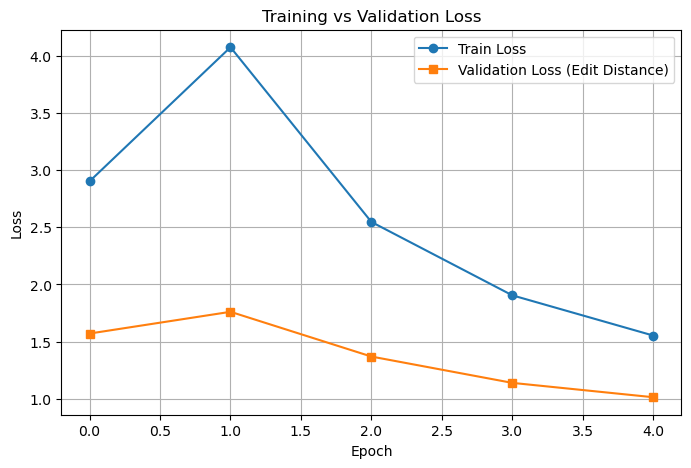

In [1]:
import matplotlib.pyplot as plt

train_losses = [2.903, 4.076, 2.547, 1.905, 1.553]
val_losses   = [1.5707, 1.7608, 1.3693, 1.1389, 1.0134]


epochs = range(len(train_losses))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='s', label="Validation Loss (Edit Distance)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()
